# Árvore de Decisão

> Objetivo: treinar uma Árvore de Decisão, **limitar a sua profundidade** para reduzir o sobreajuste e avaliar o desempenho no conjunto de teste.

> O pré-processamento (imputação + one-hot encoding) é partilhado através de `preprocessing.py`, sendo ajustado apenas com o treino dentro de uma pipeline.

## 1) Importação e leitura dos dados

In [10]:
# importações de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

import preprocessing as prep

# Carregamento com as transformações determinísticas; imputação/encoding ficam
# na pipeline . Não se usa o ortho_eda_clean.csv (já imputado).
X, y = prep.carregar_dados()

## 2) Preparação dos dados

In [11]:
# Split estratificado único. O teste é usado uma só vez, no fim.
X_train, X_test, y_train, y_test = prep.dividir_treino_teste(X, y)
print("treino:", X_train.shape, "| teste:", X_test.shape)

treino: (183, 13) | teste: (79, 13)


## 3) Árvore de decisão: baseline

In [12]:
# Baseline: Árvore de Decisão SEM limitação de profundidade.
# Serve para evidenciar a existência de sobreajuste: ajusta o treino na perfeição mas
# generaliza mal 
pipe_dt_base = prep.construir_pipeline(
    DecisionTreeClassifier(random_state=42), X
)
pipe_dt_base.fit(X_train, y_train)

print("Accuracy no treino:", round(pipe_dt_base.score(X_train, y_train), 4))
print("Accuracy no teste :", round(pipe_dt_base.score(X_test, y_test), 4))
print("Profundidade da árvore:", pipe_dt_base.named_steps["modelo"].get_depth())

Accuracy no treino: 1.0
Accuracy no teste : 0.8101
Profundidade da árvore: 7


# 3.1) Avaliação do modelo

              precision    recall  f1-score   support

           0     0.9118    0.8732    0.8921        71
           1     0.1818    0.2500    0.2105         8

    accuracy                         0.8101        79
   macro avg     0.5468    0.5616    0.5513        79
weighted avg     0.8378    0.8101    0.8231        79

AUC (probabilidades): 0.5616


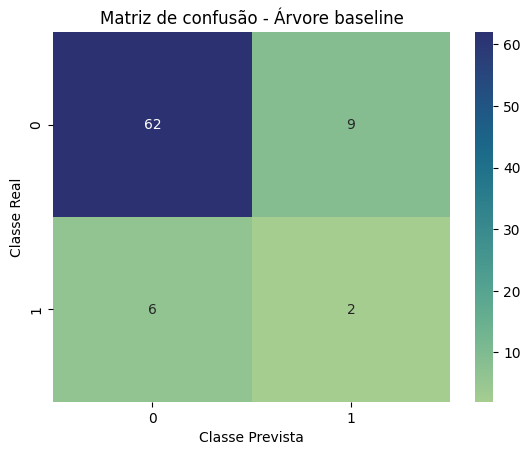

In [13]:
# Avaliação do baseline no teste: matriz de confusão + relatório + AUC (probabilidades)
res_dt_base = prep.avaliar_teste(pipe_dt_base, X_test, y_test, titulo="Árvore baseline")

In [14]:
# Validação cruzada estratificada APENAS no treino, AUC de probabilidades
print("=== Validação cruzada (treino) — Árvore baseline ===")
_ = prep.validacao_cruzada_treino(pipe_dt_base, X_train, y_train)

=== Validação cruzada (treino) — Árvore baseline ===
              precision    recall  f1-score   support

           0     0.9202    0.9091    0.9146       165
           1     0.2500    0.2778    0.2632        18

    accuracy                         0.8470       183
   macro avg     0.5851    0.5934    0.5889       183
weighted avg     0.8543    0.8470    0.8506       183

AUC CV (probabilidades): 0.5934


## 4) Teste simples de hipóteses (redundância de variáveis)

Avaliamos se algumas variáveis representam a mesma informação e podem ser removidas sem perda relevante de desempenho. Na EDA identificaram-se variáveis muito correlacionadas:

- `WT_0` versus os seus componentes (`WR_0`, `WD_0`, `WAtotal_0`);
- `IMC` versus as variáveis de base (`Peso`, `Altura_cm`).

Cada cenário é avaliado por **validação cruzada só no treino** e por **AUC a partir de probabilidades**, com o mesmo pré-processamento dentro da pipeline (sem data leakage).

In [15]:
# Comparação de cenários de features (Árvore rasa e balanceada), por CV no treino.
cenarios = {
    "Todas as features": [],
    "Sem WT_0": ["WT_0"],
    "Sem componentes (WD_0, WR_0, WAtotal_0)": ["WD_0", "WR_0", "WAtotal_0"],
    "Sem IMC": ["IMC"],
    "Sem Peso e Altura_cm": ["Peso", "Altura_cm"],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
linhas = []
for nome, remover in cenarios.items():
    Xc = X.drop(columns=remover)
    Xc_tr = X_train.drop(columns=remover)
    pipe = prep.construir_pipeline(
        DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42),
        Xc,
    )
    proba = cross_val_predict(pipe, Xc_tr, y_train, cv=cv, method="predict_proba")[:, 1]
    linhas.append({
        "Cenário": nome,
        "n_features": Xc_tr.shape[1],
        "AUC_CV_treino": round(roc_auc_score(y_train, proba), 4),
    })

pd.DataFrame(linhas).sort_values("AUC_CV_treino", ascending=False).reset_index(drop=True)

,Cenário,n_features,AUC_CV_treino
0,"Sem componentes (WD_0, WR_0, WAtotal_0)",10,0.6934
1,Sem IMC,12,0.6717
2,Sem Peso e Altura_cm,11,0.6682
3,Todas as features,13,0.6653
4,Sem WT_0,12,0.6653


## 5) Parameter Tuning: limitar a profundidade da árvore 

A árvore sem limite sobreajusta. Em vez de fixar uma profundidade arbitrária, **afinamos `max_depth` (e `min_samples_leaf`, `class_weight`) por validação cruzada no treino**, otimizando a AUC. O melhor valor é escolhido pelos dados e não à mão.

In [16]:
# GridSearchCV sobre a pipeline, afinando a profundidade e a regularização.
# CV estratificada só no treino; scoring = AUC.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe_dt = prep.construir_pipeline(DecisionTreeClassifier(random_state=42), X)

param_grid = {
    "modelo__max_depth": [2, 3, 4, 5, 6, 8, None],
    "modelo__min_samples_leaf": [1, 2, 5, 10],
    "modelo__class_weight": [None, "balanced"],
    "modelo__criterion": ["gini", "entropy"],
}

grid_dt = GridSearchCV(
    pipe_dt, param_grid, scoring="roc_auc", cv=cv, n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print("Melhores parâmetros:", grid_dt.best_params_)
print("Melhor AUC média (CV, treino):", round(grid_dt.best_score_, 4))
melhor_prof = grid_dt.best_params_["modelo__max_depth"]
print("Profundidade escolhida (max_depth):", melhor_prof)

Melhores parâmetros: {'modelo__class_weight': None, 'modelo__criterion': 'gini', 'modelo__max_depth': 4, 'modelo__min_samples_leaf': 5}
Melhor AUC média (CV, treino): 0.7778
Profundidade escolhida (max_depth): 4


=== Avaliação no TESTE — Árvore afinada ===
              precision    recall  f1-score   support

           0     0.8974    0.9859    0.9396        71
           1     0.0000    0.0000    0.0000         8

    accuracy                         0.8861        79
   macro avg     0.4487    0.4930    0.4698        79
weighted avg     0.8066    0.8861    0.8444        79

AUC (probabilidades): 0.5423


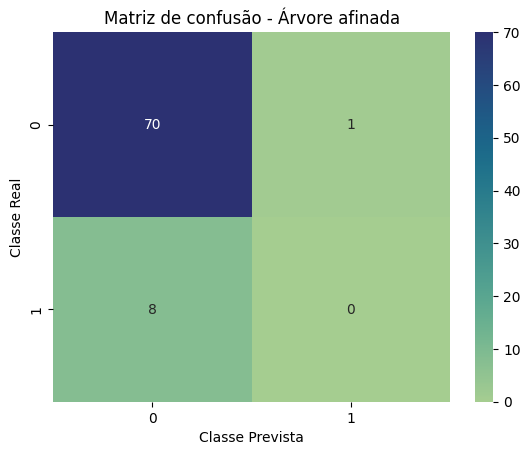


=== Validação cruzada (treino) — Árvore afinada ===
              precision    recall  f1-score   support

           0     0.9281    0.9394    0.9337       165
           1     0.3750    0.3333    0.3529        18

    accuracy                         0.8798       183
   macro avg     0.6516    0.6364    0.6433       183
weighted avg     0.8737    0.8798    0.8766       183

AUC CV (probabilidades): 0.7557

Profundidade escolhida por CV = 4: limita o sobreajuste face à árvore sem limite, mantendo a interpretabilidade.


In [17]:
# Avaliação da árvore afinada no teste (usado uma só vez) + CV no treino.
best_dt = grid_dt.best_estimator_

print("=== Avaliação no TESTE — Árvore afinada ===")
res_dt_tuned = prep.avaliar_teste(best_dt, X_test, y_test, titulo="Árvore afinada")

print("\n=== Validação cruzada (treino) — Árvore afinada ===")
_ = prep.validacao_cruzada_treino(best_dt, X_train, y_train)

# Justificação: a profundidade foi limitada por CV. Uma árvore
# rasa (poucos níveis) reduz a variância/sobreajuste e mantém a árvore
# interpretável, ao contrário da árvore sem limite que decorava o treino.
print(
    f"\nProfundidade escolhida por CV = {melhor_prof}: limita o sobreajuste "
    "face à árvore sem limite, mantendo a interpretabilidade."
)

## 6) SMOTE — exemplos sintéticos da classe minoritária 

A classe `mudanca_CPAK=1` é rara (~10%). Testamos o **SMOTE** para gerar exemplos sintéticos da minoria. Usa-se a `Pipeline` do **imbalanced-learn** para o SMOTE ser aplicado **apenas no `fit`** (folds de treino), nunca à validação/teste. Comparam-se as métricas **com** e **sem** SMOTE.

> Nota: o dataset é pequeno e a minoria tem poucos casos, pelo que os resultados do SMOTE podem ser instáveis (variam bastante entre folds).

In [18]:
# Compara a Árvore afinada COM e SEM SMOTE (mesmos hiperparâmetros de profundidade).
from sklearn.base import clone

# Sem class_weight aqui: o SMOTE já reequilibra as classes.
modelo_dt = DecisionTreeClassifier(
    random_state=42,
    max_depth=grid_dt.best_params_["modelo__max_depth"],
    min_samples_leaf=grid_dt.best_params_["modelo__min_samples_leaf"],
    criterion=grid_dt.best_params_["modelo__criterion"],
)

for etiqueta, usar_smote in [("SEM SMOTE", False), ("COM SMOTE", True)]:
    print("\n" + "=" * 55)
    print(f"Árvore afinada — {etiqueta}")
    print("=" * 55)
    pipe = prep.construir_pipeline(clone(modelo_dt), X, usar_smote=usar_smote)
    pipe.fit(X_train, y_train)
    print("--- Teste ---")
    prep.avaliar_teste(pipe, X_test, y_test, titulo=f"Árvore {etiqueta}", plot=False)
    print("--- Validação cruzada (treino) ---")
    prep.validacao_cruzada_treino(pipe, X_train, y_train)


Árvore afinada — SEM SMOTE
--- Teste ---
              precision    recall  f1-score   support

           0     0.8974    0.9859    0.9396        71
           1     0.0000    0.0000    0.0000         8

    accuracy                         0.8861        79
   macro avg     0.4487    0.4930    0.4698        79
weighted avg     0.8066    0.8861    0.8444        79

AUC (probabilidades): 0.5423
--- Validação cruzada (treino) ---
              precision    recall  f1-score   support

           0     0.9281    0.9394    0.9337       165
           1     0.3750    0.3333    0.3529        18

    accuracy                         0.8798       183
   macro avg     0.6516    0.6364    0.6433       183
weighted avg     0.8737    0.8798    0.8766       183

AUC CV (probabilidades): 0.7557

Árvore afinada — COM SMOTE
--- Teste ---
              precision    recall  f1-score   support

           0     0.8971    0.8592    0.8777        71
           1     0.0909    0.1250    0.1053         8

  